# ANSWER KEY — Areal Disaggregation Exercises: Population and Water Stress in Jamaica

**INSTRUCTOR COPY — DO NOT DISTRIBUTE TO STUDENTS**

This notebook contains acceptable answers for all exercise cells. Student answers do not need to match these exactly — there are multiple valid approaches for many steps. The key things to look for when grading are noted in comments marked `# GRADING NOTE:`.

---

In the previous notebook, we walked through a complete areal disaggregation workflow — estimating how many people live in each HUC-8 watershed in the United States by redistributing census tract populations using area-weighted ratios. Now it is your turn.

In this notebook you will apply (and extend) that same workflow using data for **Jamaica**. You have two datasets already loaded in your geodatabase:

| Feature Class | Description | Key Fields |
|---|---|---|
| `Jamaica_hydrobasins` | Watershed boundaries for Jamaica | `HYDROLOGIC` (unique watershed ID), `SURFFACE_RU` (total surface runoff in the watershed) |
| `Jamaica_population` | Parish-level administrative boundaries | `pop_1881`, `pop_1891`, `pop_1911`, `pop_1921`, `pop_1943`, `pop_1960`, `pop_1970`, `pop_1982`, `pop_2001`, `pop_2011`, `pop_2016` |

Notice an important difference from the U.S. exercise: there, the source zones were census tracts (small, many features). Here, the source zones are **parishes** — Jamaica has only 14 parishes, and they are relatively large compared to the watersheds. The uniform-distribution assumption will be weaker for large parishes that contain both dense urban areas and empty mountainous interior. Keep this in mind as you interpret your results.

The three exercises build on each other:

1. **Exercise 1** — Run the basic disaggregation for the 2016 population.
2. **Exercise 2** — Bring in surface runoff data and calculate a water-stress indicator.
3. **Exercise 3** — Generalize your code into a function and loop through all census years.

**How to work through this notebook:** Each exercise has markdown cells that explain what to do, followed by code cells with starter code and comments. Fill in the missing pieces. You are encouraged to refer back to the previous notebook — copying and adapting code is a legitimate and efficient way to work. The skill is knowing **what to change**.

---

## Setup: Imports and Environment

This cell is provided for you. Run it first to import the libraries and set the workspace. Make sure `spaWeek06.gdb` contains both Jamaica datasets.

In [79]:
# --- Setup (provided) ---

import arcpy
import os
import pandas as pd
import matplotlib.pyplot as plt

arcpy.env.workspace = r"spaWeek06.gdb"
arcpy.env.overwriteOutput = True

print("Workspace: {}".format(arcpy.env.workspace))
print("Setup complete.")

Workspace: spaWeek06.gdb
Setup complete.


---

# Exercise 1: Basic Disaggregation for Jamaica (2016 Population)

Your goal is to estimate **how many people live in each Jamaican watershed** using the 2016 parish-level population data.

The logic is identical to the U.S. exercise:

1. Record the original area of each source polygon (parish).
2. Intersect the parishes with the watershed boundaries.
3. Calculate the area-weighted estimated population for each sliver.
4. Dissolve by watershed, summing the estimates.

### What you need to think about

- Which feature class is the **source** (has the data to disaggregate) and which is the **target** (defines the zones you want to summarize into)?
- Which **population field** should you use for 2016?
- Which **ID field** uniquely identifies each watershed?
- If you copy the variable definitions from the previous notebook, which variable values need to change? Which can stay the same?

Think about this: the *structure* of the code does not change at all. Only the **variable values** at the top change. This is exactly why we organized all the inputs at the top of the script — it makes the code generalizable.

### Step 1.1 — Define your variables

Fill in the variable values below. Refer to the table at the top of this notebook and think carefully about which field holds the 2016 population.

In [80]:
# --- Exercise 1, Step 1.1: Define all variables ---
# ANSWER KEY

# GRADING NOTE: The four input variables below are the critical answers.
# Students must correctly identify which FC is the source vs. target,
# and select the correct field names.

# INPUTS
disaggFC = "Jamaica_population"       # The feature class with population data (source zones)
oPopFieldName = "pop_2016"            # The population field for 2016
overlayFC = "Jamaica_hydrobasins"     # The feature class with watershed boundaries (target zones)
oUnitsfield = "HYDROLOGIC"            # The unique ID field for each watershed

# PROCESSING
iaFieldName = "Initial_Area"

# TEMPORARY
tintersectFC = r"memory\jamaica_intersect"

# OUTPUTS
EstPopFieldName = "Estimated_Population"
disaggoutFC = "Jamaica_disagg_2016"

# DERIVED
TotalPopFieldName = "{} SUM".format(EstPopFieldName)

# Print your variables to verify
print("Source FC      : {}".format(disaggFC))
print("Pop field      : {}".format(oPopFieldName))
print("Target FC      : {}".format(overlayFC))
print("Target ID field: {}".format(oUnitsfield))

Source FC      : Jamaica_population
Pop field      : pop_2016
Target FC      : Jamaica_hydrobasins
Target ID field: HYDROLOGIC


### Step 1.2 — Validate your inputs

Copy or adapt the `validate_inputs` function from the previous notebook. Run it on your two Jamaica datasets to confirm they are both polygons, share a coordinate system, and overlap geographically.

In [81]:
# --- Exercise 1, Step 1.2: Validate inputs ---
# ANSWER KEY

# GRADING NOTE: Students should copy the function from the previous notebook
# (or write their own version) and call it. The function body does not need
# to be identical — the key is that it checks geometry type, spatial reference,
# and extent overlap. Some students may write a simpler inline version without
# a function, which is acceptable for partial credit.

def validate_inputs(fc1, fc2):
    """
    Validate that two feature classes are both polygons, share the same
    spatial reference, and have overlapping geographic extents.
    """
    all_passed = True

    desc1 = arcpy.Describe(fc1)
    desc2 = arcpy.Describe(fc2)

    # Check 1: Geometry type
    print("--- Geometry Type Check ---")
    print("  {} : {}".format(fc1, desc1.shapeType))
    print("  {} : {}".format(fc2, desc2.shapeType))
    if desc1.shapeType != "Polygon" or desc2.shapeType != "Polygon":
        print("  WARNING: Both feature classes must be Polygon type!")
        all_passed = False
    else:
        print("  PASSED")

    # Check 2: Spatial reference
    sr1 = desc1.spatialReference
    sr2 = desc2.spatialReference
    print("\n--- Spatial Reference Check ---")
    print("  {} : {}".format(fc1, sr1.name))
    print("  {} : {}".format(fc2, sr2.name))
    if sr1.name != sr2.name:
        print("  WARNING: Spatial references do not match!")
        all_passed = False
    else:
        print("  PASSED")

    # Check 3: Extent overlap
    ext1 = desc1.extent
    ext2 = desc2.extent
    print("\n--- Extent Overlap Check ---")
    overlaps = not (ext1.XMax < ext2.XMin or ext1.XMin > ext2.XMax or
                    ext1.YMax < ext2.YMin or ext1.YMin > ext2.YMax)
    if not overlaps:
        print("  WARNING: Extents do NOT overlap!")
        all_passed = False
    else:
        print("  PASSED")

    print("\n=== Validation {} ===".format("PASSED" if all_passed else "FAILED"))
    return all_passed

is_valid = validate_inputs(disaggFC, overlayFC)

--- Geometry Type Check ---
  Jamaica_population : Polygon
  Jamaica_hydrobasins : Polygon
  PASSED

--- Spatial Reference Check ---
  Jamaica_population : Lambert Conformal Conic
  Jamaica_hydrobasins : Lambert Conformal Conic
  PASSED

--- Extent Overlap Check ---
  PASSED

=== Validation PASSED ===


### Step 1.3 — Calculate the original area of each parish

Use `CalculateField` to add and populate the `Initial_Area` field on the source feature class. This records each parish's area before the intersect splits it.

In [83]:
# --- Exercise 1, Step 1.3: Calculate initial area ---
# ANSWER KEY

# GRADING NOTE: The essential elements are:
#   - Correct in_table (disaggFC or "Jamaica_population")
#   - Correct field name (iaFieldName or "Initial_Area")
#   - Expression uses !shape.area!
#   - Field type is DOUBLE (or FLOAT — acceptable alternative)

arcpy.management.CalculateField(
    in_table=disaggFC,
    field=iaFieldName,
    expression="!shape.area!",
    expression_type="PYTHON3",
    code_block="",
    field_type="DOUBLE"
)

print("Initial_Area calculated on {}".format(disaggFC))
print(arcpy.GetMessages())

Initial_Area calculated on Jamaica_population
Start Time: Wednesday, March 4, 2026 4:03:53 PM
Succeeded at Wednesday, March 4, 2026 4:03:53 PM (Elapsed Time: 0.09 seconds)


### Step 1.4 — Run the Pairwise Intersect

Intersect the parish boundaries with the watershed boundaries. Remember to write the result to the in-memory workspace. After the tool finishes, print the feature count so you can see how many slivers were created.

In [84]:
# --- Exercise 1, Step 1.4: Pairwise Intersect ---
# ANSWER KEY

# GRADING NOTE: The essential elements are:
#   - Both FCs are listed in in_features (order doesn't matter)
#   - Output goes to the in-memory workspace (tintersectFC)
#   - join_attributes is "ALL"
#   Students may also use arcpy.analysis.Intersect instead of
#   PairwiseIntersect — this is acceptable.

arcpy.analysis.PairwiseIntersect(
    in_features="{};{}".format(disaggFC, overlayFC),
    out_feature_class=tintersectFC,
    join_attributes="ALL",
    cluster_tolerance=None,
    output_type="INPUT"
)

intersect_count = arcpy.management.GetCount(tintersectFC)
print("Pairwise Intersect complete.")
print("Output features: {}".format(intersect_count))
print(arcpy.GetMessages())

Pairwise Intersect complete.
Output features: 43
Start Time: Wednesday, March 4, 2026 4:03:57 PM
Row Count = 43
Succeeded at Wednesday, March 4, 2026 4:03:57 PM (Elapsed Time: 0.01 seconds)


### Step 1.5 — Calculate the estimated population for each sliver

Apply the area-weighted formula. Remember the expression:

$$\text{Estimated Population} = \frac{\text{Sliver Area}}{\text{Original Parish Area}} \times \text{Original Parish Population}$$

Use the variables you defined above — do not hard-code field names into the expression string.

In [86]:
# --- Exercise 1, Step 1.5: Calculate estimated population ---
# ANSWER KEY

# GRADING NOTE: The critical piece is the expression string.
#   - Must use !shape.area! for the sliver area (current geometry)
#   - Must divide by !Initial_Area! (the original parish area)
#   - Must multiply by !pop_2016! (the population field)
#   - Using .format() with variables is best practice but hard-coded
#     field names are acceptable for partial credit.
#   - Field type LONG is correct (integer people). DOUBLE is acceptable.

expression = "(!shape.area! / !{}!) * !{}!".format(iaFieldName, oPopFieldName)
print("Expression: {}".format(expression))

arcpy.management.CalculateField(
    in_table=tintersectFC,
    field=EstPopFieldName,
    expression=expression,
    expression_type="PYTHON3",
    code_block="",
    field_type="LONG"
)

print("Estimated population calculated for each sliver.")
print(arcpy.GetMessages())

Expression: (!shape.area! / !Initial_Area!) * !pop_2016!
Estimated population calculated for each sliver.
Start Time: Wednesday, March 4, 2026 4:04:16 PM
Adding Estimated_Population to jamaica_intersect...
Succeeded at Wednesday, March 4, 2026 4:04:16 PM (Elapsed Time: 0.07 seconds)


### Step 1.6 — Dissolve by watershed

Dissolve the slivers by the watershed ID field, summing the estimated populations. This produces your final output — one polygon per watershed with a total estimated population.

In [87]:
# --- Exercise 1, Step 1.6: Pairwise Dissolve ---
# ANSWER KEY

# GRADING NOTE: The essential elements are:
#   - in_features is the intersect result (tintersectFC)
#   - dissolve_field is the watershed ID (oUnitsfield / "HYDROLOGIC")
#   - statistics_fields sums the estimated population
#   Students may use arcpy.management.Dissolve instead of
#   PairwiseDissolve — this is acceptable.

arcpy.analysis.PairwiseDissolve(
    in_features=tintersectFC,
    out_feature_class=disaggoutFC,
    dissolve_field=oUnitsfield,
    statistics_fields=TotalPopFieldName,
    multi_part="MULTI_PART"
)

print("Pairwise Dissolve complete.")
print("Output: {}".format(disaggoutFC))
print(arcpy.GetMessages())

Pairwise Dissolve complete.
Output: Jamaica_disagg_2016
Start Time: Wednesday, March 4, 2026 4:04:25 PM
Sorting Attributes...
Dissolving...
Succeeded at Wednesday, March 4, 2026 4:04:26 PM (Elapsed Time: 0.63 seconds)


### Step 1.7 — View the results and verify

Print the attribute table of your dissolved output. Then compare the total original population to the total estimated population as a sanity check.

Optionally, add the dissolved layer to the map and symbolize it with graduated colors.

In [88]:
# --- Exercise 1, Step 1.7: View results and verify totals ---
# ANSWER KEY

# GRADING NOTE: Students should (a) print the table and (b) compare totals.
# The exact formatting does not matter. The totals comparison is the important part.

sum_field = "SUM_{}".format(EstPopFieldName)

# Print the attribute table
print("{:<15} {:>22}".format(oUnitsfield, sum_field))
print("-" * 39)
with arcpy.da.SearchCursor(disaggoutFC, [oUnitsfield, sum_field]) as cursor:
    for row in cursor:
        print("{:<15} {:>22,}".format(row[0], row[1]))

# Compare totals
original_total = 0
with arcpy.da.SearchCursor(disaggFC, [oPopFieldName]) as cursor:
    for row in cursor:
        if row[0] is not None:
            original_total += row[0]

estimated_total = 0
with arcpy.da.SearchCursor(disaggoutFC, [sum_field]) as cursor:
    for row in cursor:
        if row[0] is not None:
            estimated_total += row[0]

difference = original_total - estimated_total
pct_diff = (difference / original_total) * 100 if original_total != 0 else 0

print("\nOriginal total population  : {:>12,}".format(original_total))
print("Estimated total population : {:>12,}".format(estimated_total))
print("Difference                 : {:>12,}".format(difference))
print("Percent difference         : {:>11.2f}%".format(pct_diff))

HYDROLOGIC      SUM_Estimated_Population
---------------------------------------
Black River                  190,643.0
Blue Mountain North              326,537.0
Blue Mountain South              168,525.0
Cabarita River               166,816.0
Dry Harbour Mountains              213,456.0
Great River                  207,702.0
Kingston                     380,833.0
Martha Brae River               73,354.0
Rio Cobre                    583,428.0
Rio Minho                    396,867.0

Original total population  :    2,726,230
Estimated total population :  2,708,161.0
Difference                 :     18,069.0
Percent difference         :        0.66%


### Step 1.8 — Create a bar chart

Read the dissolved output into a pandas DataFrame and create a horizontal bar chart of estimated population by watershed, just as we did in the previous notebook.

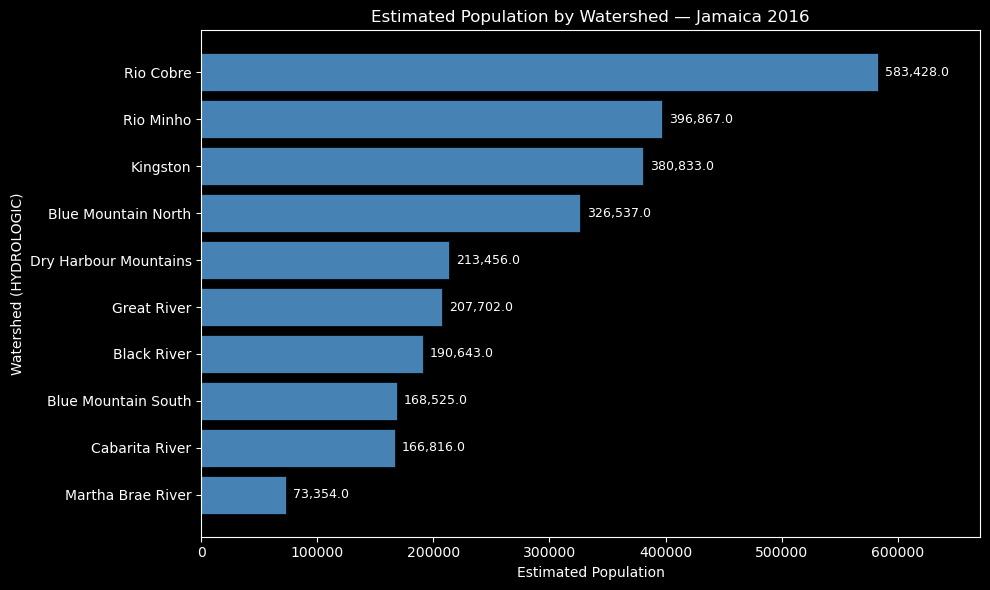

In [89]:
# --- Exercise 1, Step 1.8: Bar chart of population by watershed ---
# ANSWER KEY

# GRADING NOTE: Any reasonable bar chart (horizontal or vertical) with
# labeled axes and a title is acceptable. The exact styling, colors,
# and sorting do not need to match.

sum_field = "SUM_{}".format(EstPopFieldName)

rows = []
with arcpy.da.SearchCursor(disaggoutFC, [oUnitsfield, sum_field]) as cursor:
    for row in cursor:
        rows.append({"HYDROLOGIC": row[0], "Estimated_Pop": row[1]})

df = pd.DataFrame(rows)
df = df.sort_values("Estimated_Pop", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df) * 0.4)))
ax.barh(df["HYDROLOGIC"], df["Estimated_Pop"], color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Estimated Population")
ax.set_ylabel("Watershed (HYDROLOGIC)")
ax.set_title("Estimated Population by Watershed — Jamaica 2016")

for index, value in enumerate(df["Estimated_Pop"]):
    ax.text(value + (df["Estimated_Pop"].max() * 0.01), index, "{:,}".format(value),
            va="center", fontsize=9)

ax.set_xlim(0, df["Estimated_Pop"].max() * 1.15)
plt.tight_layout()
plt.show()

---

# Exercise 2: Water Stress Analysis

Now that you have estimated population by watershed, we can go a step further. The `Jamaica_hydrobasins` feature class contains a field called `SURFFACE_RU`, which represents the **total surface runoff** for each watershed. Surface runoff is a useful (if simplified) proxy for the **available fresh water supply** in a watershed.

Your task is to combine the population estimate from Exercise 1 with the surface runoff value to calculate a **water-stress indicator** — a number that tells us how much available water there is per person in each watershed.

### The metric

We will calculate:

$$\text{Surface Runoff per Capita} = \frac{\text{SURFFACE\_RU}}{\text{SUM\_Estimated\_Population}}$$

A **lower** value means more people are sharing less water — greater water stress. A **higher** value means more water is available per person. The watershed with the **lowest** surface runoff per capita is under the greatest water stress.

### The problem: the data lives in different feature classes

Your dissolved output from Exercise 1 has the population estimates, but it does **not** have the `SURFFACE_RU` field — that field is in the original `Jamaica_hydrobasins` feature class. You need to bring `SURFFACE_RU` into your dissolved output.

**Hint:** You need to perform a **Join**. Both datasets share the watershed ID field (`HYDROLOGIC`), so you can use `arcpy.management.JoinField` to permanently append `SURFFACE_RU` from the hydrobasins feature class onto your dissolved output. The syntax is:

```python
arcpy.management.JoinField(
    in_data=<your dissolved output>,
    in_field=<the watershed ID field>,
    join_table=<the hydrobasins feature class>,
    join_field=<the same watershed ID field>,
    fields=[<the field(s) you want to bring over>]
)
```

After the join, both `SUM_Estimated_Population` and `SURFFACE_RU` will be in the same table, and you can calculate the per-capita ratio with `CalculateField`.

### Step 2.1 — Join the surface runoff field to your dissolved output

Use `JoinField` to attach `SURFFACE_RU` from `Jamaica_hydrobasins` to your Exercise 1 dissolved output. After the join, list the fields to confirm `SURFFACE_RU` is now present.

In [93]:
# --- Exercise 2, Step 2.1: Join surface runoff to dissolved output ---
# ANSWER KEY

# GRADING NOTE: The key elements are:
#   - in_data is the dissolved output (disaggoutFC / "Jamaica_disagg_2016")
#   - in_field and join_field are both HYDROLOGIC
#   - join_table is the hydrobasins FC
#   - fields includes "SURFFACE_RU"
#   Students may also use AddJoin + CalculateField + RemoveJoin, which is
#   an acceptable alternative approach.

arcpy.management.JoinField(
    in_data=disaggoutFC,
    in_field=oUnitsfield,
    join_table=overlayFC,
    join_field=oUnitsfield,
    fields=["SURFACE_RU"]
)

print("Join complete.")

# List fields to confirm
print("\nFields after join:")
for field in arcpy.ListFields(disaggoutFC):
    print("  {:<30} {}".format(field.name, field.type))

Join complete.

Fields after join:
  OBJECTID                       OID
  Shape                          Geometry
  HYDROLOGIC                     String
  SUM_Estimated_Population       Double
  Shape_Length                   Double
  Shape_Area                     Double
  Runoff_Per_Capita              Double
  SURFACE_RU                     Double


### Step 2.2 — Calculate Surface Runoff per Capita

Add a new field and calculate the ratio of surface runoff to estimated population. Use the `DOUBLE` field type since this will be a decimal value.

**Be careful:** If any watershed has an estimated population of zero, dividing by it will cause an error. You may want to add a conditional expression or simply verify that no watershed has zero population first.

In [94]:
# --- Exercise 2, Step 2.2: Calculate runoff per capita ---
# ANSWER KEY

# GRADING NOTE: The essential elements are:
#   - Divides SURFFACE_RU by SUM_Estimated_Population
#   - Field type is DOUBLE (or FLOAT)
#   - Bonus: handles division by zero (but not required)
#   Acceptable alternative: students may use a SearchCursor + UpdateCursor
#   or build the result in pandas instead.

runoff_per_cap_field = "Runoff_Per_Capita"
sum_field = "SUM_{}".format(EstPopFieldName)

# Simple version (assumes no zero-population watersheds):
expression = "!SURFACE_RU! / !{}!".format(sum_field)

# Safer version with zero check (acceptable alternative):
# expression = "!SURFFACE_RU! / !{}! if !{}! > 0 else 0".format(sum_field, sum_field)

arcpy.management.CalculateField(
    in_table=disaggoutFC,
    field=runoff_per_cap_field,
    expression=expression,
    expression_type="PYTHON3",
    code_block="",
    field_type="DOUBLE"
)

print("Runoff per capita calculated.")
print(arcpy.GetMessages())

Runoff per capita calculated.
Start Time: Wednesday, March 4, 2026 4:09:31 PM
Succeeded at Wednesday, March 4, 2026 4:09:32 PM (Elapsed Time: 0.11 seconds)


### Step 2.3 — Identify the most water-stressed watershed

Read the results into a pandas DataFrame, sort by `Runoff_Per_Capita`, and print the table. Create a bar chart to visualize the values.

**Answer this question in a comment or a print statement:** Which watershed has the lowest surface runoff per capita, and is therefore under the greatest water stress?

Water Stress by Watershed (sorted by Runoff Per Capita, ascending):
           HYDROLOGIC  Estimated_Pop  Surface_Runoff  Runoff_Per_Capita
             Kingston       380833.0            81.0           0.000213
            Rio Cobre       583428.0           187.0           0.000321
            Rio Minho       396867.0           225.0           0.000567
          Black River       190643.0           346.0           0.001815
Dry Harbour Mountains       213456.0           457.0           0.002141
          Great River       207702.0           467.0           0.002248
       Cabarita River       166816.0           420.0           0.002518
    Martha Brae River        73354.0           279.0           0.003803
  Blue Mountain South       168525.0           662.0           0.003928
  Blue Mountain North       326537.0          2452.0           0.007509


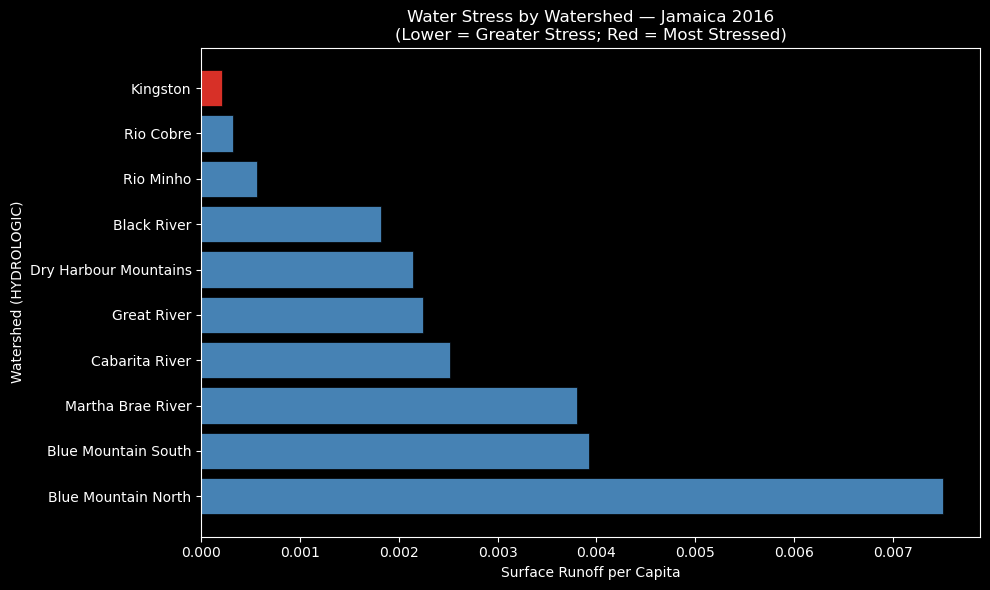


The most water-stressed watershed is: Kingston
  Estimated Population : 380,833
  Surface Runoff       : 81.00
  Runoff Per Capita    : 0.0002


In [95]:
# --- Exercise 2, Step 2.3: Identify the most water-stressed watershed ---
# ANSWER KEY

# GRADING NOTE: Students must:
#   (a) Print or display the data sorted by runoff per capita
#   (b) Create some kind of chart
#   (c) Identify the watershed with the LOWEST runoff per capita
#   The specific watershed ID will depend on the data.
#   Chart style/formatting is flexible.

sum_field = "SUM_{}".format(EstPopFieldName)

# Read into a DataFrame
rows = []
with arcpy.da.SearchCursor(disaggoutFC, [oUnitsfield, sum_field, "SURFACE_RU", runoff_per_cap_field]) as cursor:
    for row in cursor:
        rows.append({
            "HYDROLOGIC": row[0],
            "Estimated_Pop": row[1],
            "Surface_Runoff": row[2],
            "Runoff_Per_Capita": row[3]
        })

df_stress = pd.DataFrame(rows)

# Sort by runoff per capita (ascending = most stressed first)
df_stress = df_stress.sort_values("Runoff_Per_Capita", ascending=True).reset_index(drop=True)

print("Water Stress by Watershed (sorted by Runoff Per Capita, ascending):")
print(df_stress.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, max(6, len(df_stress) * 0.4)))

# Sort ascending for bottom-to-top display (most stressed at top)
df_plot = df_stress.sort_values("Runoff_Per_Capita", ascending=False).reset_index(drop=True)

colors = ["#d73027" if v == df_plot["Runoff_Per_Capita"].min() else "steelblue" for v in df_plot["Runoff_Per_Capita"]]

ax.barh(df_plot["HYDROLOGIC"], df_plot["Runoff_Per_Capita"], color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Surface Runoff per Capita")
ax.set_ylabel("Watershed (HYDROLOGIC)")
ax.set_title("Water Stress by Watershed — Jamaica 2016\n(Lower = Greater Stress; Red = Most Stressed)")
plt.tight_layout()
plt.show()

# Answer the question
most_stressed = df_stress.iloc[0]
print("\nThe most water-stressed watershed is: {}".format(most_stressed["HYDROLOGIC"]))
print("  Estimated Population : {:,.0f}".format(most_stressed["Estimated_Pop"]))
print("  Surface Runoff       : {:,.2f}".format(most_stressed["Surface_Runoff"]))
print("  Runoff Per Capita    : {:,.4f}".format(most_stressed["Runoff_Per_Capita"]))

---

# Exercise 3: Multi-Year Analysis Using a Loop and a Function

So far, you have run the disaggregation for a single year (2016). But the `Jamaica_population` dataset contains population fields for **eleven different census years**:

`pop_1881`, `pop_1891`, `pop_1911`, `pop_1921`, `pop_1943`, `pop_1960`, `pop_1970`, `pop_1982`, `pop_2001`, `pop_2011`, `pop_2016`

Running the same analysis eleven times by copying and pasting the code would be tedious and error-prone. This is exactly the situation where **functions** and **loops** pay off.

### The plan

1. **Wrap the disaggregation workflow in a function** that takes a population field name as a parameter and returns a DataFrame with the results for that year.
2. **Loop through all eleven years**, calling the function each time.
3. **Collect the results** into a single DataFrame so you can compare populations across years.

### A quick refresher on functions

A function packages a block of reusable code behind a name. You define it with `def`, list its **parameters** (the inputs that change each time), and use `return` to send a result back to the caller.

```python
def disaggregate_population(pop_field, year_label):
    """
    Run the full disaggregation workflow for one population field.
    Returns a DataFrame with columns: HYDROLOGIC, Estimated_Pop, Year
    """
    # ... all the geoprocessing steps go here ...
    # ... read the dissolved result into a DataFrame ...
    # ... add a 'Year' column so we can tell the years apart later ...
    return df
```

Think about what should be **inside** the function (everything that changes per year or that needs to run each time) versus what should stay **outside** (things that are constant, like the workspace and the input feature class names).

### Getting started with the loop

Here is the skeleton of the loop. The list of years and the corresponding field names are provided. Your job is to complete the function body.

```python
years = [1881, 1891, 1911, 1921, 1943, 1960, 1970, 1982, 2001, 2011, 2016]

all_results = []

for year in years:
    pop_field = "pop_{}".format(year)
    print("Processing {}...".format(pop_field))
    df = disaggregate_population(pop_field, year)
    all_results.append(df)

# Combine all years into one DataFrame
combined_df = pd.concat(all_results, ignore_index=True)
```

**Important implementation detail:** Each time the function runs, it will perform an intersect and a dissolve. Make sure you use a **unique output name** for each year's dissolve result (e.g., `"Jamaica_disagg_{}".format(year)`) so that you do not overwrite the previous year's output. The in-memory intersect can be reused each iteration since we set `overwriteOutput = True`.

Also note: the `Initial_Area` field only needs to be calculated **once** on the parish feature class (it does not change between years). You can either calculate it before the loop, or add a check inside the function to skip it if the field already exists.

### Step 3.1 — Calculate Initial Area (once, before the loop)

If you already ran Exercise 1, this field may already exist. It will not hurt to recalculate it — the values will be the same. This ensures the field is ready before the loop starts.

In [97]:
# --- Exercise 3, Step 3.1: Calculate initial area (once) ---
# (Provided in both student and key versions)

disaggFC = "Jamaica_population"
overlayFC = "Jamaica_hydrobasins"
oUnitsfield = "HYDROLOGIC"
iaFieldName = "Initial_Area"

arcpy.management.CalculateField(
    in_table=disaggFC,
    field=iaFieldName,
    expression="!shape.area!",
    expression_type="PYTHON3",
    code_block="",
    field_type="DOUBLE"
)

print("Initial_Area calculated on {}".format(disaggFC))

Initial_Area calculated on Jamaica_population


### Step 3.2 — Write the disaggregation function

Complete the function below. It should:

1. Run Pairwise Intersect (parishes × watersheds) — use the in-memory workspace.
2. Calculate the area-weighted estimated population using the provided `pop_field`.
3. Dissolve by `HYDROLOGIC`, summing the estimated population.
4. Read the dissolved result into a pandas DataFrame.
5. Add a `Year` column so we can identify which year each row belongs to.
6. Return the DataFrame.

Most of the code can be adapted directly from what you wrote in Exercise 1. The key difference is that the population field name and the output feature class name are now **parameters** instead of hard-coded values.

In [100]:
# --- Exercise 3, Step 3.2: Define the disaggregation function ---
# ANSWER KEY

# GRADING NOTE: The three geoprocessing calls (Steps A, B, C) are the
# critical pieces students must fill in. They should be essentially the
# same as Exercise 1, but using the function parameters (pop_field, out_fc)
# instead of hard-coded values. The rest of the function was provided.
#
# Common mistakes to watch for:
#   - Using oPopFieldName (hard-coded to "pop_2016") instead of pop_field
#   - Using disaggoutFC instead of out_fc for the dissolve output
#   - Forgetting to use stat_field in the dissolve

def disaggregate_population(pop_field, year):
    """
    Run the area-weighted disaggregation for a single population field
    and return the results as a pandas DataFrame.

    Parameters
    ----------
    pop_field : str  — Name of the population field (e.g., "pop_2016")
    year      : int  — The census year (used for labeling and output naming)

    Returns
    -------
    pandas.DataFrame with columns: HYDROLOGIC, Estimated_Pop, Year
    """
    # Use these variables (already defined above this cell)
    # disaggFC, overlayFC, oUnitsfield, iaFieldName

    EstPopFieldName = "Estimated_Population"
    tintersectFC = r"memory\jamaica_intersect"
    out_fc = "Jamaica_disagg_{}".format(year)
    stat_field = "{} SUM".format(EstPopFieldName)

    # Step A: Pairwise Intersect
    arcpy.analysis.PairwiseIntersect(
        in_features="{};{}".format(disaggFC, overlayFC),
        out_feature_class=tintersectFC,
        join_attributes="ALL",
        cluster_tolerance=None,
        output_type="INPUT"
    )

    # Step B: Calculate estimated population for each sliver
    # NOTE: uses pop_field (the function parameter), NOT a hard-coded field name
    expression = "(!shape.area! / !{}!) * !{}!".format(iaFieldName, pop_field)
    arcpy.management.CalculateField(
        in_table=tintersectFC,
        field=EstPopFieldName,
        expression=expression,
        expression_type="PYTHON3",
        code_block="",
        field_type="LONG"
    )

    # Step C: Pairwise Dissolve by watershed
    # NOTE: uses out_fc (unique per year), NOT a hard-coded output name
    arcpy.analysis.PairwiseDissolve(
        in_features=tintersectFC,
        out_feature_class=out_fc,
        dissolve_field=oUnitsfield,
        statistics_fields=stat_field,
        multi_part="MULTI_PART"
    )

    # Step D: Read the dissolved output into a DataFrame
    sum_field = "SUM_{}".format(EstPopFieldName)
    rows = []
    with arcpy.da.SearchCursor(out_fc, [oUnitsfield, sum_field]) as cursor:
        for row in cursor:
            rows.append({"HYDROLOGIC": row[0], "Estimated_Pop": row[1]})

    df = pd.DataFrame(rows)
    df["Year"] = year  # Add the year label

    print("  {} complete — {} watersheds".format(pop_field, len(df)))
    return df

### Step 3.3 — Run the loop

The loop below iterates through all eleven census years, calls your function for each one, and collects the results. Once the loop finishes, we concatenate all the individual DataFrames into a single combined DataFrame.

Most of this cell is provided. Make sure your function from Step 3.2 is working correctly before running it.

In [101]:
# --- Exercise 3, Step 3.3: Loop through all census years ---
# (Provided in both student and key versions)

years = [1881, 1891, 1911, 1921, 1943, 1960, 1970, 1982, 2001, 2011, 2016]

all_results = []

for year in years:
    pop_field = "pop_{}".format(year)
    print("Processing {}...".format(pop_field))
    df = disaggregate_population(pop_field, year)
    all_results.append(df)

# Combine all years into one DataFrame
combined_df = pd.concat(all_results, ignore_index=True)

print("\nAll years processed.")
print("Combined DataFrame: {} rows x {} columns".format(*combined_df.shape))
print(combined_df.head(20))

Processing pop_1881...
  pop_1881 complete — 10 watersheds
Processing pop_1891...
  pop_1891 complete — 10 watersheds
Processing pop_1911...
  pop_1911 complete — 10 watersheds
Processing pop_1921...
  pop_1921 complete — 10 watersheds
Processing pop_1943...
  pop_1943 complete — 10 watersheds
Processing pop_1960...
  pop_1960 complete — 10 watersheds
Processing pop_1970...
  pop_1970 complete — 10 watersheds
Processing pop_1982...
  pop_1982 complete — 10 watersheds
Processing pop_2001...
  pop_2001 complete — 10 watersheds
Processing pop_2011...
  pop_2011 complete — 10 watersheds
Processing pop_2016...
  pop_2016 complete — 10 watersheds

All years processed.
Combined DataFrame: 110 rows x 3 columns
               HYDROLOGIC  Estimated_Pop  Year
0             Black River        62212.0  1881
1     Blue Mountain North        74642.0  1881
2     Blue Mountain South        37204.0  1881
3          Cabarita River        58133.0  1881
4   Dry Harbour Mountains        60604.0  1881
5     

### Step 3.4 — Visualize population change over time

Now that you have estimated populations for every watershed across eleven census years, create a **line chart** that shows how population has changed over time. Use matplotlib to plot one line per watershed, with the x-axis as the census year and the y-axis as the estimated population.

**Hint:** You will need to restructure the DataFrame. A **pivot table** is a convenient way to do this:

```python
pivot_df = combined_df.pivot(index="Year", columns="HYDROLOGIC", values="Estimated_Pop")
```

This gives you a table with years as rows and watersheds as columns — perfect for plotting. Then `pivot_df.plot()` will draw one line per column.

If the chart is too crowded with all watersheds, consider plotting only the five most populated watersheds (based on the 2016 values).

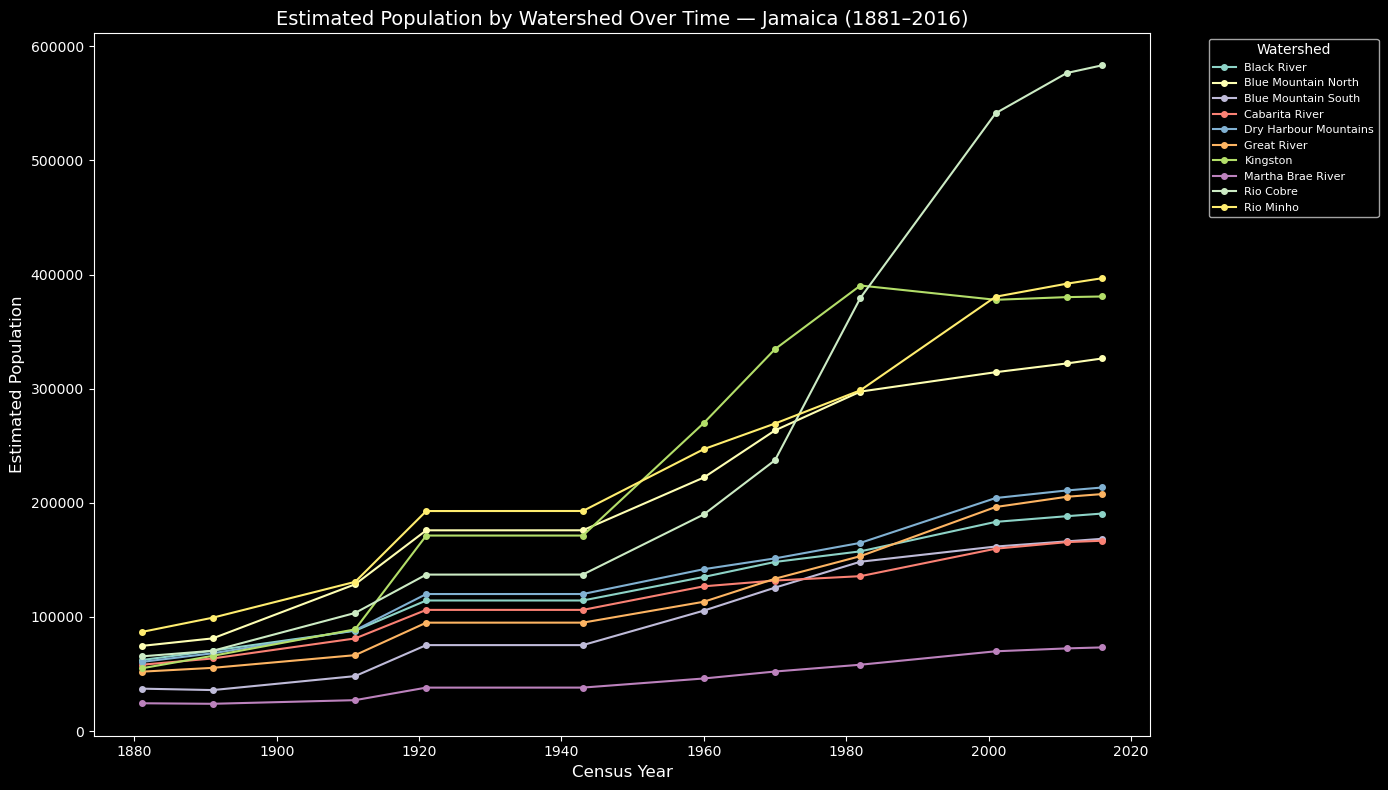

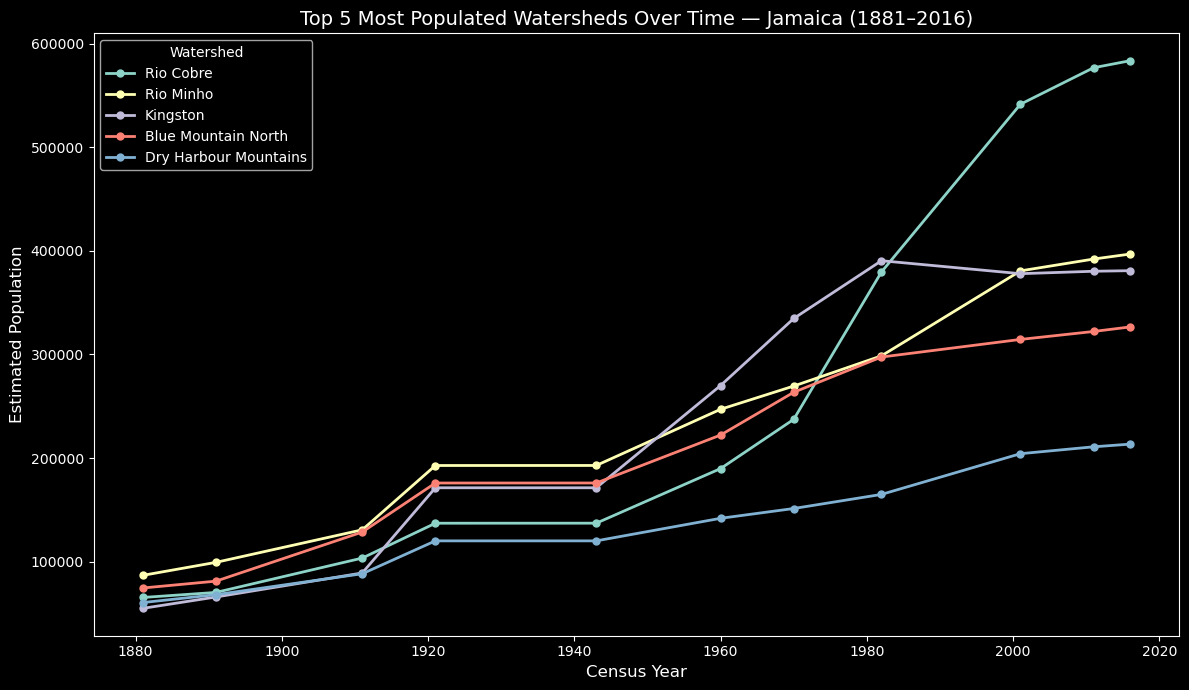

In [102]:
# --- Exercise 3, Step 3.4: Line chart of population over time ---
# ANSWER KEY

# GRADING NOTE: Any reasonable line chart showing population trends
# over time is acceptable. Students may plot all watersheds or a subset.
# The pivot approach is suggested but not required — students could
# also loop through watersheds and plot each line manually.
# Must have: labeled axes, a title, and a legend (or some way to
# identify which line is which).

# Pivot the data: rows = years, columns = watersheds
pivot_df = combined_df.pivot(index="Year", columns="HYDROLOGIC", values="Estimated_Pop")

# Full chart with all watersheds
fig, ax = plt.subplots(figsize=(14, 8))
pivot_df.plot(ax=ax, marker="o", linewidth=1.5, markersize=4)

ax.set_xlabel("Census Year", fontsize=12)
ax.set_ylabel("Estimated Population", fontsize=12)
ax.set_title("Estimated Population by Watershed Over Time — Jamaica (1881–2016)", fontsize=14)
ax.legend(title="Watershed", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

# Optional: Top 5 most populated watersheds in 2016
top5 = pivot_df.loc[2016].nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))
pivot_df[top5].plot(ax=ax, marker="o", linewidth=2, markersize=5)

ax.set_xlabel("Census Year", fontsize=12)
ax.set_ylabel("Estimated Population", fontsize=12)
ax.set_title("Top 5 Most Populated Watersheds Over Time — Jamaica (1881–2016)", fontsize=14)
ax.legend(title="Watershed", fontsize=10)

plt.tight_layout()
plt.show()

### Step 3.5 — Reflection

In the cell below, write a brief comment (or print statement) addressing these questions:

1. Which watershed(s) have seen the most population growth over the 135-year period?
2. Are there any watersheds where population has **declined** or remained stable?
3. How does the uniform-distribution assumption affect the reliability of the earlier census years (1881, 1891) versus the more recent ones? Think about how Jamaica's settlement patterns may have changed over that period.
4. What would you change or add to make this analysis more rigorous?

In [103]:
# --- Exercise 3, Step 3.5: Reflection ---
# ANSWER KEY

# GRADING NOTE: These are open-ended questions. Look for thoughtful
# engagement with the data and the methodology, not specific answers.
# The responses below are examples of strong answers.

# 1. Which watershed(s) have seen the most population growth?
#    Answer will depend on the data, but students should identify
#    specific watershed(s) from their chart/table and cite the numbers.
#    Watersheds containing Kingston/St. Andrew are likely candidates.

# 2. Declining or stable population?
#    Students should look for flat or downward-trending lines in
#    their chart. Rural mountainous interior watersheds may show
#    slower growth or stability.

# 3. Uniform-distribution assumption across time:
#    Strong answers will note that Jamaica's population was more
#    rurally distributed in 1881 (closer to uniform), while modern
#    Jamaica is heavily urbanized (Kingston metro area has ~670,000+).
#    So the assumption may actually be LESS wrong for earlier years
#    and MORE wrong for recent years where urban concentration is
#    higher. However, the parish boundaries are very large, so the
#    assumption is weak for all years.

# 4. Improvements:
#    Acceptable answers include:
#    - Use smaller source zones (enumeration districts instead of parishes)
#    - Dasymetric weighting with land cover or building footprints
#    - Use address-level data or gridded population products (WorldPop, etc.)
#    - Account for the fact that parish boundaries may have changed over
#      the 135-year period
#    - Use population density rather than total population for the
#      water stress calculation

print("See GRADING NOTE comments above for acceptable reflection answers.")

See GRADING NOTE comments above for acceptable reflection answers.


---

## You Are Done!

In these exercises you:

- Applied an existing workflow to a new dataset by changing only the input variables.
- Extended the analysis by joining ancillary data and calculating a derived water-stress metric.
- Generalized the workflow into a reusable function and automated it with a loop across eleven census years.

These are fundamental software engineering practices — **parameterization**, **modularity**, and **automation** — and they are the foundation of everything we will build in this course going forward, including custom toolboxes.

In [ ]:
print("Exercises complete!")